## Model for Prediction:

### Acknowledgements for Build a Model to Predict the Sales

### Purposes:
- Goal: Build a model that can be an indicator, in percentage, if a deal has the potential to close WON or NOT
- This model can help Managers to see, in a vast amount of deals, those that have the highest potential to close;
- This model can help SalesPerson to prioritise their pipeline and analyse deals;

### Interpretability:
- The model needs to be Interpretable. Because when the model makes a prediction, it needs to be easy to understand what features was more important to return an specific results (and them, the Specialist SalesPerson/Manager make its own conclusions based on their point of view and based on the Context of the Deal)

### Considerations about the Features:

##### Hypothesis of Features that have the biggest potential to close deals, in order of priority:

- Account Type
- Country
- Segment
- Type of the Business
- Opp Value (EUR)

### Considerations about the Days that the deal is Open:

- The Variable Deal Opened (Days), as saw in the Exploratory Data Analysis, presents an expressive difference in mean between WONs and LOSTs, which makes it an important indicator to predict if a deal will became a WON or LOST.

##### How to incorporate this metric?

- As the time pass since the day the deal was created, the probability of the deal close changes. It changes a litle bit day after day.

- As saw, the general mean of WON deals is in ~34 days and the general mean of LOST is at ~76 days. It means that, when a deal pass aproximate of its day 34, its chance to close increase and after this, decrease. And if it still remain open, according it approximate of day 76, the chance of LOST just get higher.
Of course, it is just in general terms, which means that when we consider other features, like Account Type and Segment, these means changes. However, we consider those other variables when create a model to predict sales.

- Time Deal Opened (Days) : Get the Day the deal has been created - the Day of Today, and incorporate the result (a number in magnitude in days) in the model.

#### Notes:
- Considerando um valor geral sem cortes na análise, pude observar que deals LOST tem um tempo médio maior que deals WON, um vesultado expressivo de ~76 dias versus ~34 dias.

🔍 Pontos Positivos da sua Abordagem
Diferença significativa nas médias:

A diferença entre os tempos médios de deals WON (~34 dias) e LOST (~76 dias) é estatisticamente relevante e pode, sim, ser um indicador forte de conversão.
Se essa diferença for confirmada por testes estatísticos (como um teste t de diferença de médias), ela pode ser um bom preditor.
A evolução da probabilidade ao longo do tempo:

A ideia de que a probabilidade de fechamento muda ao longo do tempo faz sentido, pois a distribuição dos tempos sugere que há períodos mais propícios para o fechamento.
Isso se alinha com modelos estatísticos como Curvas de Sobrevivência (Kaplan-Meier) e Modelos de Hazard (Cox Regression), que analisam o tempo até um evento ocorrer.
Possível implementação no modelo:

Incorporar "quantos dias o deal está aberto" como uma variável no modelo é uma abordagem lógica, pois trata-se de um indicador temporal importante.
Além de um simples valor numérico, pode-se criar variáveis categóricas para diferentes faixas de tempo (ex: 0-30 dias, 31-60 dias, 61-90 dias, etc.) para capturar padrões mais profundos.
⚠️ Críticas e Pontos de Atenção
Médias podem enganar: analisar a distribuição

A média por si só pode ser enganosa, pois não leva em conta a distribuição completa dos dados.
O ideal é verificar a dispersão (desvio padrão, quartis) e se a distribuição é assimétrica.
Se a distribuição do tempo aberto for assimétrica (ex: muitos deals fechando logo no início e alguns poucos ficando abertos por muito tempo), a mediana pode ser um indicador mais confiável que a média.
Causalidade x Correlação

O tempo aberto pode não ser a causa direta de um deal ser WON ou LOST, mas sim um efeito colateral de outros fatores (ex: deals de menor valor fecham mais rápido, deals de grandes empresas demoram mais, etc.).
Sugestão: Testar se essa variável ainda tem impacto significativo no modelo depois de controlar outros fatores.
Impacto de variáveis ocultas

Você mencionou corretamente que outras variáveis como Account Type e Segment afetam os tempos médios.
Isso pode indicar que o tempo aberto não é um preditor independente, mas sim um reflexo dessas características.
Modelagem mais avançada pode ser necessária

Se quiser modelar melhor essa relação, uma opção mais sofisticada seria um modelo de sobrevivência (Survival Analysis), que mede a chance de um deal ser fechado conforme o tempo passa.
Modelos como Cox Proportional Hazards podem dar insights sobre o efeito do tempo aberto na probabilidade de fechamento.
🚀 Conclusão e Sugestões
✅ Faz sentido usar o tempo aberto como preditor, pois há uma diferença significativa entre WON e LOST
⚠️ Mas é importante analisar a distribuição dos dados e controlar variáveis que podem influenciar o tempo de fechamento
📌 Testes estatísticos, curvas de sobrevivência e visualizações como histogramas e boxplots podem ajudar a validar essa hipótese antes de incluir a variável no modelo

Se quiser rodar algum teste estatístico para validar isso ou construir gráficos para explorar melhor essa relação, me avise! 🔍📊

### Sobre interpretabilidade:

## Exploring Data

In [268]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pickle
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

""" Just for Google Colab:
from google.colab import drive

drive.mount('/content/drive')
data = pd.read_csv("/content/drive/Othercomputers/Meu laptop/Documents/Projects/merck_business_case/data/sales_preprocessed_data.csv")
"""
# To Load the data when run Locally:
data = pd.read_csv("data/sales_preprocessed_data.csv")

data["Created Date"] = pd.to_datetime(data["Created Date"], errors="coerce")
data["Close Date"] = pd.to_datetime(data["Close Date"], errors="coerce")

print(data.info())

print("Drop NaN and plot the result:")
data = data.dropna()
print(data.isnull().sum())

data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84268 entries, 0 to 84267
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Unnamed: 0               84268 non-null  int64         
 1   Opportunity Name         84268 non-null  object        
 2   Created Date             84268 non-null  datetime64[ns]
 3   Close Date               84268 non-null  datetime64[ns]
 4    Account Name            84268 non-null  object        
 5    Account Type            84268 non-null  object        
 6    Opp Value (EUR)         82959 non-null  float64       
 7   Stage                    84268 non-null  object        
 8   Opportunity Owner        84268 non-null  object        
 9   Country                  84268 non-null  object        
 10  Region                   84268 non-null  object        
 11  Segment                  84268 non-null  object        
 12  Lead Source              84268 n

,Unnamed: 0,Opportunity Name,Created Date,Close Date,Account Name,Account Type,Opp Value (EUR),Stage,Opportunity Owner,Country,Region,Segment,Lead Source,Type,Primary Campaign Source,Close Reason,Business Type,Deal Opened (Days)
0,0,Opp 1,2023-03-01,2024-01-25,Account 1,Small,994.000,Closed Lost,Sales Specialist 1,Country 1,Region 1,Unknown,Unknown,New Business,Campaing 1,Project/Budget Cancelled/Out of Business,Unknown,330
1,1,Opp 2,2024-02-19,2024-03-02,Account 2,Top 2,6.000,Closed Won,Sales Specialist 2,Country 1,Region 1,Segment 1,Unknown,New Business,Campaing 1,Automatically closed,Unknown,12
2,2,Opp 7,2023-10-18,2024-01-22,Account 7,Small,2.157,Closed Lost,Sales Specialist 6,Country 1,Region 1,Segment 3,Referral,New Business,Campaing 5,Price,Unknown,96
3,3,Opp 8,2023-06-16,2024-02-04,Account 8,Small,183.000,Closed Lost,Sales Specialist 7,Country 1,Region 1,Unknown,Unknown,Existing Business,Campaing 5,Unable to Confirm Sale,Unknown,233
4,4,Opp 9,2023-05-04,2024-02-04,Account 8,Small,372.000,Closed Lost,Sales Specialist 7,Country 1,Region 1,Unknown,Unknown,New Business,Campaing 5,Unable to Confirm Sale,Unknown,276


c:\Users\danrl\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4824: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


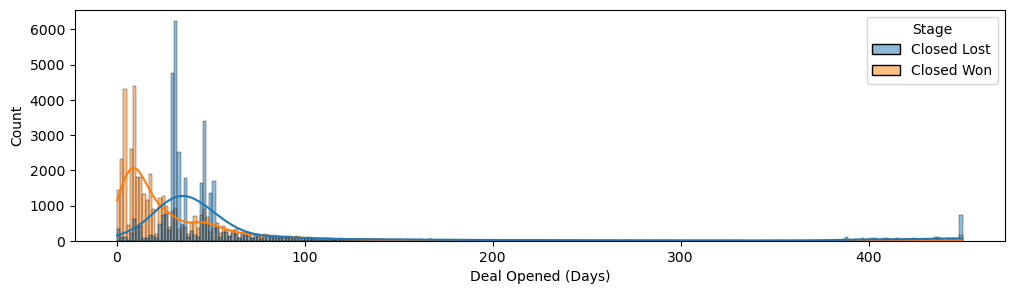

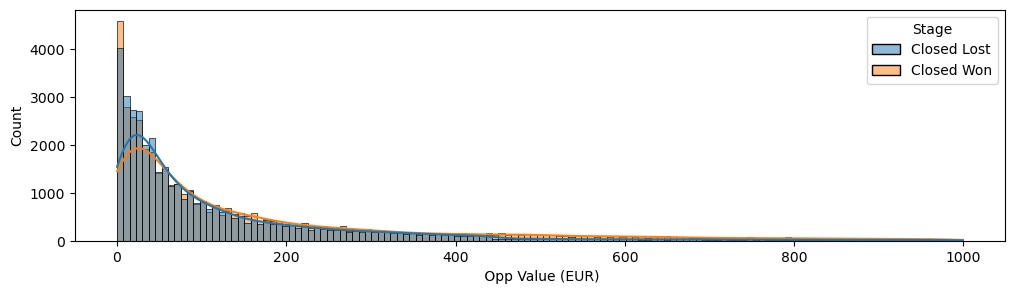

count    82959.000000
mean       146.222402
std        189.582519
min          0.000000
25%         24.000000
50%         69.000000
75%        189.000000
max        999.000000
Name:  Opp Value (EUR), dtype: float64

In [269]:
import pandas as pd
from scipy.stats.mstats import winsorize

# Ajustar tamanho do gráfico
plt.figure(figsize=(12, 3))  # Largura = 12, Altura = 6

# Winsorização com limite de 1% e 99% de percentis
data['Deal Opened (Days)'] = winsorize(data['Deal Opened (Days)'], limits=[0.01, 0.01])

# Verificando os resultados
data['Deal Opened (Days)'].describe()

# Criar histograma
sns.histplot(data, x="Deal Opened (Days)", hue="Stage", kde=True)

# Exibir o gráfico
plt.show()

# Ajustar tamanho do gráfico
plt.figure(figsize=(12, 3))  # Largura = 12, Altura = 6

# Winsorização com limite de 1% e 99% de percentis
#data[' Opp Value (EUR)'] = winsorize(data[' Opp Value (EUR)'], limits=[0.01, 0.01])

# Criar histograma
sns.histplot(data, x=" Opp Value (EUR)", hue="Stage", kde=True)

# Exibir o gráfico
plt.show()

# Verificando os resultados
data[' Opp Value (EUR)'].describe()

In [270]:
data_to_model = data[[" Account Type", "Country", "Segment", "Type", " Opp Value (EUR)", "Stage"]]

print("🔵 Number of instances per category:")

print(data_to_model[" Account Type"].value_counts())
print(data_to_model["Country"].value_counts())
print(data_to_model["Segment"].value_counts())
print(data_to_model["Type"].value_counts())

data_to_model = data_to_model[    (data_to_model["Segment"] != "Unknown") &     (data_to_model["Type"].isin(["New Business", "Existing Business"]))]

print("🔵 After the Last Drop Number of instances per category:")

print(data_to_model["Segment"].value_counts())
print(data_to_model["Type"].value_counts())
len(data_to_model)

🔵 Number of instances per category:
 Account Type
Top 3    39850
Small    22861
Top 2    12866
Top 1     7382
Name: count, dtype: int64
Country
Country 2    56614
Country 5    13288
Country 1    13057
Name: count, dtype: int64
Segment
Segment 1    31270
Segment 2    24440
Segment 3    21798
Segment 4     3792
Unknown       1659
Name: count, dtype: int64
Type
Existing Business         64680
New Business              17579
Unknown                     694
Other                         5
Competitive conversion        1
Name: count, dtype: int64
🔵 After the Last Drop Number of instances per category:
Segment
Segment 1    30807
Segment 2    24325
Segment 3    21709
Segment 4     3773
Name: count, dtype: int64
Type
Existing Business    63405
New Business         17209
Name: count, dtype: int64


80614

### Encoder

In [6]:
# Definir o OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse_output=False)

# Selecionar as colunas para aplicar o OneHotEncoder
columns_to_encode = [' Account Type', 'Country', 'Segment', 'Type']

# Aplicar OneHotEncoder nas colunas selecionadas
encoded_data = encoder.fit_transform(data_to_model[columns_to_encode])

# Criar um DataFrame com as colunas codificadas
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(columns_to_encode))

# Concatenar as colunas codificadas de volta ao DataFrame original (sem as colunas originais)
data_to_model_encoded = pd.concat([encoded_df, data_to_model.drop(columns=columns_to_encode)], axis=1)

data_to_model_encoded['Stage_Num'] = data_to_model_encoded['Stage'].map({'Closed Won': 1, 'Closed Lost': 0})

# Visualizar as primeiras linhas
data_to_model_encoded.head()

,Account Type_ Top 1,Account Type_ Top 2,Account Type_ Top 3,Country_Country 2,Country_Country 5,Segment_Segment 2,Segment_Segment 3,Segment_Segment 4,Type_New Business,Opp Value (EUR),Stage,Stage_Num
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,6.000,Closed Won,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,2.157,Closed Lost,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,NaN,NaN,NaN


In [7]:
print(data_to_model_encoded.info())
# Verificando valores NaN nas colunas de data_to_model_1 antes do split
print(data_to_model_encoded.isnull().sum())
data_to_model_encoded = data_to_model_encoded.dropna()
print(data_to_model_encoded.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 84106 entries, 0 to 84267
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0    Account Type_ Top 1  80614 non-null  float64
 1    Account Type_ Top 2  80614 non-null  float64
 2    Account Type_ Top 3  80614 non-null  float64
 3   Country_Country 2     80614 non-null  float64
 4   Country_Country 5     80614 non-null  float64
 5   Segment_Segment 2     80614 non-null  float64
 6   Segment_Segment 3     80614 non-null  float64
 7   Segment_Segment 4     80614 non-null  float64
 8   Type_New Business     80614 non-null  float64
 9    Opp Value (EUR)      80614 non-null  float64
 10  Stage                 80614 non-null  object 
 11  Stage_Num             80614 non-null  float64
dtypes: float64(11), object(1)
memory usage: 8.3+ MB
None
 Account Type_ Top 1    3492
 Account Type_ Top 2    3492
 Account Type_ Top 3    3492
Country_Country 2       3492
Country_

In [8]:
X = data_to_model_encoded.drop(["Stage", "Stage_Num"], axis=1)
y = data_to_model_encoded["Stage_Num"]

print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(X_train.info())

print(y_train.value_counts())

X_train.head()

Stage_Num
1.0    41153
0.0    35969
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 61697 entries, 57073 to 17238
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0    Account Type_ Top 1  61697 non-null  float64
 1    Account Type_ Top 2  61697 non-null  float64
 2    Account Type_ Top 3  61697 non-null  float64
 3   Country_Country 2     61697 non-null  float64
 4   Country_Country 5     61697 non-null  float64
 5   Segment_Segment 2     61697 non-null  float64
 6   Segment_Segment 3     61697 non-null  float64
 7   Segment_Segment 4     61697 non-null  float64
 8   Type_New Business     61697 non-null  float64
 9    Opp Value (EUR)      61697 non-null  float64
dtypes: float64(10)
memory usage: 5.2 MB
None
Stage_Num
1.0    32987
0.0    28710
Name: count, dtype: int64


,Account Type_ Top 1,Account Type_ Top 2,Account Type_ Top 3,Country_Country 2,Country_Country 5,Segment_Segment 2,Segment_Segment 3,Segment_Segment 4,Type_New Business,Opp Value (EUR)
57073,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,153.000
79943,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.195
67700,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,31.000
43103,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,199.000
47851,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,86.000


In [9]:
# Scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled

array([[-0.31839932, -0.43339185,  1.03233944, ..., -0.22332886,
        -0.51672907,  0.03108906],
       [-0.31839932,  2.30738071, -0.96867364, ..., -0.22332886,
        -0.51672907, -0.76646931],
       [ 3.1407102 , -0.43339185, -0.96867364, ..., -0.22332886,
        -0.51672907, -0.60987877],
       ...,
       [-0.31839932, -0.43339185,  1.03233944, ..., -0.22332886,
        -0.51672907, -0.72546313],
       [-0.31839932, -0.43339185,  1.03233944, ..., -0.22332886,
        -0.51672907,  1.86993119],
       [-0.31839932,  2.30738071, -0.96867364, ..., -0.22332886,
        -0.51672907, -0.66767095]])

# Losgistic Regression:

### Cross-Val - Logistic Regression

In [9]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
import numpy as np

# Definir o modelo
model_lr = LogisticRegression(max_iter=1000, random_state=42)

# Definir as métricas que queremos avaliar
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Aplicar Cross-Validation com X folds
cv_results = cross_validate(model_lr, X_train_scaled, y_train, cv=10, scoring=scoring)

# Exibir as métricas médias e desvios padrões
for metric in scoring:
    mean_score = np.mean(cv_results[f'test_{metric}'])
    std_score = np.std(cv_results[f'test_{metric}'])
    print(f"{metric.capitalize()} - Média: {mean_score:.4f}, Desvio Padrão: {std_score:.4f}")

Accuracy - Média: 0.5393, Desvio Padrão: 0.0048
Precision - Média: 0.5581, Desvio Padrão: 0.0036
Recall - Média: 0.6646, Desvio Padrão: 0.0103
F1 - Média: 0.6067, Desvio Padrão: 0.0056


### GridSearch - Logistic Regression

In [13]:
# Rodando o GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

# Definir o modelo base
model_lr = LogisticRegression(random_state=42)

param_grid = [
    # Testando l1 com liblinear e saga
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1'], 'solver': ['liblinear', 'saga'], 'max_iter': [500, 1000, 2000]},

    # Testando l2 com lbfgs e saga
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l2'], 'solver': ['lbfgs', 'saga'], 'max_iter': [500, 1000, 2000]},

    # Testando elasticnet com saga (precisa de l1_ratio)
    {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['elasticnet'], 'solver': ['saga'], 'max_iter': [500, 1000, 2000], 'l1_ratio': [0.1, 0.5, 0.9]}
]

# Criar o GridSearchCV
grid_search = GridSearchCV(
    model_lr,
    param_grid,
    scoring='accuracy',  # Usando F1-score como métrica principal
    cv=5,  # Cross-validation com 5 folds
    n_jobs=-1,  # Usa todos os processadores disponíveis
    verbose=2  # Mostra progresso da busca
)

# Treinar o modelo com GridSearch
grid_search.fit(X_train_scaled, y_train)

# Exibir os melhores hiperparâmetros encontrados
print("Melhores hiperparâmetros:", grid_search.best_params_)
print("Melhor F1-score:", grid_search.best_score_)

# Melhor modelo treinado
best_model_lr = grid_search.best_estimator_

# Avaliar no conjunto de teste
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = best_model_lr.predict(X_test_scaled)

print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred):.4f}")

# Pegando os coeficientes
coef_df = pd.DataFrame(
    {"Feature": X_train.columns, "Coeficiente": best_model_lr.coef_[0]}
).sort_values(by="Coeficiente", ascending=False)

print(coef_df)

Fitting 5 folds for each of 126 candidates, totalling 630 fits
Melhores hiperparâmetros: {'C': 0.001, 'l1_ratio': 0.1, 'max_iter': 500, 'penalty': 'elasticnet', 'solver': 'saga'}
Melhor F1-score: 0.5407232998951947
Acurácia: 0.5359
Precisão: 0.5476
Recall: 0.7101
F1-score: 0.6184


Melhores hiperparâmetros #1: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}
- Acurácia: 0.6614
- Precisão: 0.6832
- Recall: 0.6918
- F1-score: 0.6874

Melhores hiperparâmetros #2: {'C': 0.1, 'l1_ratio': 0.9, 'max_iter': 2000, 'penalty': 'elasticnet', 'solver': 'saga'}
- Acurácia: 0.6616
- Precisão: 0.6835
- Recall: 0.6918
- F1-score: 0.6876

Depois dos ajustes do Encoder:
Melhores hiperparâmetros: {'C': 0.01, 'max_iter': 500, 'penalty': 'l1', 'solver': 'saga'}
- Acurácia: 0.5369
- Precisão: 0.5513
- Recall: 0.6725
- F1-score: 0.6059

### Final Model - Logistic Regression

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
# Suponha que X_train seja seu conjunto de features e y_train o alvo

model_lr = LogisticRegression(C=0.1,
                              l1_ratio=0.9,
                              max_iter=4000,
                              random_state=42,
                              penalty='elasticnet',
                              solver='saga')

model_lr.fit(X_train_scaled, y_train)

# Pegando os coeficientes
coef_df = pd.DataFrame(
    {"Feature": X_train.columns, "Coeficiente": model_lr.coef_[0]}
).sort_values(by="Coeficiente", ascending=False)

print(coef_df)

# Fazer previsões no conjunto de teste
y_pred = model_lr.predict(X_test_scaled)

# Calcular métricas individualmente
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Exibir os resultados
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

# Exibir relatório completo
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

                   Feature  Coeficiente
11         Opp Value (EUR)     0.225947
5        Segment_Segment 2     0.037996
6        Segment_Segment 3     0.033378
7        Segment_Segment 4     0.021223
0      Account Type_ Top 1     0.012479
2      Account Type_ Top 3     0.010602
1      Account Type_ Top 2     0.004092
8   Type_Existing Business     0.000000
10              Type_Other    -0.006717
9        Type_New Business    -0.027982
4        Country_Country 5    -0.091194
3        Country_Country 2    -0.161295
Acurácia: 0.5377
Precisão: 0.5549
Recall: 0.6347
F1-score: 0.5921

Relatório de Classificação:
              precision    recall  f1-score   support

         0.0       0.51      0.43      0.47      7271
         1.0       0.55      0.63      0.59      8155

    accuracy                           0.54     15426
   macro avg       0.53      0.53      0.53     15426
weighted avg       0.53      0.54      0.53     15426



### Predictions - Logistic Regression

In [62]:
print(data_to_model[" Account Type"].unique())
print(data_to_model["Country"].unique())
print(data_to_model["Segment"].unique())
print(data_to_model["Type"].unique())

[' Top 2' ' Small' ' Top 3' ' Top 1']
['Country 1' 'Country 2' 'Country 5']
['Segment 1' 'Segment 3' 'Segment 2' 'Segment 4']
['New Business' 'Existing Business']


In [ ]:
# Crie um DataFrame com os dados da nova entrada
nova_entrada = pd.DataFrame({
    ' Account Type': [' Small'],
    'Country': ['Country 1'],
    'Segment': ['Segment 1'],
    'Type': ['New Business'],
    ' Opp Value (EUR)': [10000]
}, index=[0])  # Use index=[0] para garantir que o DataFrame tenha um índice

# Aplique OneHotEncoding
encoded_nova_entrada = encoder.transform(nova_entrada[[' Account Type', 'Country', 'Segment', 'Type']])
encoded_nova_entrada_df = pd.DataFrame(encoded_nova_entrada, columns=encoder.get_feature_names_out([' Account Type', 'Country', 'Segment', 'Type']))

# Concatene as colunas codificadas e ' Opp Value (EUR)'
nova_entrada_final = pd.concat([encoded_nova_entrada_df, nova_entrada[[' Opp Value (EUR)']].reset_index(drop=True)], axis=1)

# Aplique StandardScaler
nova_entrada_scaled = scaler.transform(nova_entrada_final)

# Faz a predição
previsao = model_lr.predict(nova_entrada_scaled)

# Imprime a predição
print(previsao)  # Output: [1] (por exemplo, prevendo "Closed Won")

# Obtem as probabilidades
probabilidades = model_lr.predict_proba(nova_entrada_scaled)

# Imprime as probabilidades
print(probabilidades)  # Output: [[0.3 0.7]] (por exemplo, 30% de chance de "Closed Lost", 70% de chance de "Closed Won")
# Imprime os coeficientes do modelo
print(coef_df)

[1.]
[[6.41376904e-06 9.99993586e-01]]
                   Feature  Coeficiente
11         Opp Value (EUR)     0.225947
5        Segment_Segment 2     0.037996
6        Segment_Segment 3     0.033378
7        Segment_Segment 4     0.021223
0      Account Type_ Top 1     0.012479
2      Account Type_ Top 3     0.010602
1      Account Type_ Top 2     0.004092
8   Type_Existing Business     0.000000
10              Type_Other    -0.006717
9        Type_New Business    -0.027982
4        Country_Country 5    -0.091194
3        Country_Country 2    -0.161295


# Evaluating Other Models:

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay, auc, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb # LGBMClassifier (LightGBM, muito eficiente para grandes volumes de dados
from sklearn.ensemble import ExtraTreesClassifier # ExtraTreesClassifier (variação do Random Forest, mais rápido e robusto a ruídos)
from sklearn.ensemble import HistGradientBoostingClassifier # HistGradientBoostingClassifier (versão otimizada do Gradient Boosting para grandes datasets)
from sklearn.neural_network import MLPClassifier # MLPClassifier (rede neural simples, pode ser útil dependendo dos padrões nos dados)
from sklearn.ensemble import StackingClassifier

# Modelos
log_clf = LogisticRegression(solver='lbfgs', max_iter=1000)
rnd_clf = RandomForestClassifier()
svm_clf = SVC()
knn_clf = KNeighborsClassifier()
grd_clf = GradientBoostingClassifier()
xgb_clf = xgb.XGBClassifier()
lgbm_clf = lgb.LGBMClassifier()
ext_clf = ExtraTreesClassifier()
hgb_clf = HistGradientBoostingClassifier()
mlp_clf = MLPClassifier(max_iter=1000)

# Para um modelo final mais forte, você pode testar uma combinação mais robusta no VotingClassifier ou um StackingClassifier:

voting_clf = VotingClassifier(
    estimators=[
        ('lr', log_clf),
        ('rf', rnd_clf),
        ('xgb', xgb_clf)
    ],
    voting='soft'
)

stack_clf = StackingClassifier(
    estimators=[
        ('lr', log_clf),
        ('xgb', xgb_clf),
        ('lgbm', lgbm_clf),
        ('mlp', mlp_clf)
    ],
    final_estimator=LogisticRegression()
)

In [32]:
for clf in (log_clf, rnd_clf, svm_clf, knn_clf, grd_clf, xgb_clf, lgbm_clf, ext_clf, hgb_clf, mlp_clf, voting_clf):
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    print(f"The {clf.__class__.__name__}  has an Accuracy: {accuracy_score(y_test, y_pred):.4f} , Precision of: {precision_score(y_test, y_pred):.4f}, Recal: {recall_score(y_test, y_pred):.4f}, F1: {f1_score(y_test, y_pred):.4f}")


The LogisticRegression  has an Accuracy: 0.5365 , Precision of: 0.5520, Recal: 0.6608, F1: 0.6015
The RandomForestClassifier  has an Accuracy: 0.5212 , Precision of: 0.5478, Recal: 0.5485, F1: 0.5481
The SVC  has an Accuracy: 0.5443 , Precision of: 0.5653, Recal: 0.6030, F1: 0.5835
The KNeighborsClassifier  has an Accuracy: 0.5356 , Precision of: 0.5577, Recal: 0.5937, F1: 0.5751
The GradientBoostingClassifier  has an Accuracy: 0.5570 , Precision of: 0.5712, Recal: 0.6544, F1: 0.6100
The XGBClassifier  has an Accuracy: 0.5512 , Precision of: 0.5692, Recal: 0.6264, F1: 0.5964
[LightGBM] [Info] Number of positive: 32987, number of negative: 28710
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006360 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 282
[LightGBM] [Info] Number of data points in the train set: 61697, number of used features

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


The LGBMClassifier  has an Accuracy: 0.5582 , Precision of: 0.5754, Recal: 0.6315, F1: 0.6021
The ExtraTreesClassifier  has an Accuracy: 0.5231 , Precision of: 0.5542, Recal: 0.5073, F1: 0.5297
The HistGradientBoostingClassifier  has an Accuracy: 0.5579 , Precision of: 0.5745, Recal: 0.6359, F1: 0.6037
The MLPClassifier  has an Accuracy: 0.5424 , Precision of: 0.5511, Recal: 0.7323, F1: 0.6289
The VotingClassifier  has an Accuracy: 0.5365 , Precision of: 0.5570, Recal: 0.6079, F1: 0.5813


# Catboost:

In [16]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 7.5 MB/s eta 0:00:00


In [20]:
import catboost
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay, auc, roc_curve

### Using Categorical Variables:

In [12]:
print(data_to_model.info())
data_to_model.head()

<class 'pandas.core.frame.DataFrame'>
Index: 80614 entries, 1 to 84267
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0    Account Type     80614 non-null  object 
 1   Country           80614 non-null  object 
 2   Segment           80614 non-null  object 
 3   Type              80614 non-null  object 
 4    Opp Value (EUR)  80614 non-null  float64
 5   Stage             80614 non-null  object 
dtypes: float64(1), object(5)
memory usage: 4.3+ MB
None


,Account Type,Country,Segment,Type,Opp Value (EUR),Stage
1,Top 2,Country 1,Segment 1,New Business,6.000,Closed Won
2,Small,Country 1,Segment 3,New Business,2.157,Closed Lost
6,Small,Country 1,Segment 3,New Business,1.456,Closed Lost
7,Top 3,Country 1,Segment 3,Existing Business,551.000,Closed Won
8,Small,Country 1,Segment 3,Existing Business,1.312,Closed Lost


## Base Model - CatBoost

In [21]:
categorical_features = [' Account Type', 'Country', 'Segment', 'Type']

cat_clf_base = CatBoostClassifier(
    cat_features=categorical_features,
    verbose=0
)

X_cat = data_to_model.drop(["Stage"], axis=1)
y_cat = data_to_model["Stage"].map({'Closed Won': 1, 'Closed Lost': 0})

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_cat, y_cat, test_size=0.20, random_state=42)

cat_clf_base.fit(X_train_cat, y_train_cat)

y_pred_cat = cat_clf_base.predict(X_test_cat)

print(f"Acurácia: {accuracy_score(y_test_cat, y_pred_cat):.4f}")
print(f"Precisão: {precision_score(y_test_cat, y_pred_cat):.4f}")
print(f"Recall: {recall_score(y_test_cat, y_pred_cat):.4f}")
print(f"F1-score: {f1_score(y_test_cat, y_pred_cat):.4f}")

Acurácia: 0.6866
Precisão: 0.7251
Recall: 0.6558
F1-score: 0.6887


In [22]:
# Print the parameters of the model
print(cat_clf_base.get_params())

# Print the feature importance
print(cat_clf_base.get_feature_importance())

# Or for a general overview:
print(cat_clf_base)

print(cat_clf_base.feature_names_)

{'verbose': 0, 'cat_features': [' Account Type', 'Country', 'Segment', 'Type']}
[10.11851069 32.74461454 17.53473353  5.46478614 34.13735509]
[' Account Type', 'Country', 'Segment', 'Type', ' Opp Value (EUR)']


## Optuna Hyperparameters Tunning - CatBoost

In [42]:
# !pip install optuna
import optuna
import catboost
from catboost import CatBoostClassifier

# Função objetivo para otimizar hiperparâmetros
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000, step=100),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10, log=True),
        'verbose': 0,
        'task_type': 'CPU'  # Se estiver em GPU, mude para 'GPU'
    }

    # Criar e treinar o modelo
    model = CatBoostClassifier(cat_features=categorical_features,
                               **params)

    model.fit(X_train_cat, y_train_cat, eval_set=(X_test_cat, y_test_cat), early_stopping_rounds=50, verbose=0)

    # Fazer previsões e calcular F1-score
    y_pred = model.predict(X_test_cat)


    return f1_score(y_test_cat, y_pred)


def objective_weighted(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000, step=100),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 10, log=True),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10, log=True),
        'verbose': 0,
        'task_type': 'CPU'  # Se estiver em GPU, mude para 'GPU'
    }

    model = CatBoostClassifier(cat_features=categorical_features,
                               **params)

    model.fit(X_train_cat, y_train_cat, eval_set=(X_test_cat, y_test_cat), early_stopping_rounds=50, verbose=0)

    y_pred = model.predict(X_test_cat)

    # Calcular as métricas
    accuracy = accuracy_score(y_test_cat, y_pred)
    precision = precision_score(y_test_cat, y_pred)
    recall = recall_score(y_test_cat, y_pred)
    f1 = f1_score(y_test_cat, y_pred)

    # Retornar uma métrica ponderada
    return 0.3 * accuracy + 0.2 * precision + 0.2 * recall + 0.3 * f1  # Ajuste os pesos conforme necessário


# Criar o estudo e rodar a otimização
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)  # Número de buscas (pode aumentar se quiser melhor ajuste)
                                         # Posso  # Aumentar número de trials para explorar mais a busca
# Melhor conjunto de hiperparâmetros
print("Melhores Hiperparâmetros:", study.best_params)

[I 2025-02-27 14:15:36,265] A new study created in memory with name: no-name-dd00c91b-34eb-4e6c-af72-fbeb37fbd453
[I 2025-02-27 14:15:51,456] Trial 0 finished with value: 0.6843796342066238 and parameters: {'iterations': 600, 'depth': 4, 'learning_rate': 0.25308306728269453, 'l2_leaf_reg': 0.036114849530021226, 'border_count': 130, 'bagging_temperature': 0.2425007274298696, 'random_strength': 3.740240927545835}. Best is trial 0 with value: 0.6843796342066238.
[I 2025-02-27 14:16:18,979] Trial 1 finished with value: 0.6906343306318933 and parameters: {'iterations': 200, 'depth': 9, 'learning_rate': 0.012339483467403054, 'l2_leaf_reg': 6.5552745779066415, 'border_count': 138, 'bagging_temperature': 0.5482145201649586, 'random_strength': 8.539809833678544e-08}. Best is trial 1 with value: 0.6906343306318933.
[I 2025-02-27 14:16:21,019] Trial 2 finished with value: 0.6833022668510613 and parameters: {'iterations': 100, 'depth': 6, 'learning_rate': 0.023503380895901007, 'l2_leaf_reg': 0.377

Melhores Hiperparâmetros: {'iterations': 200, 'depth': 9, 'learning_rate': 0.012339483467403054, 'l2_leaf_reg': 6.5552745779066415, 'border_count': 138, 'bagging_temperature': 0.5482145201649586, 'random_strength': 8.539809833678544e-08}


In [30]:
### Best parameters with Optuna:

best_params = {
    'iterations': 100,
    'depth': 6,
    'learning_rate': 0.016734116119349253,
    'l2_leaf_reg': 5.888236191810746,
    'border_count': 66,
    'bagging_temperature': 0.41777008293560736,
    'random_strength': 9.638652204014715,
    'verbose': 0, #adicionei para não printar o processo de treinamento
    'task_type': 'CPU' #adicionei para especificar o tipo de processamento
}

### Outputs:
Acurácia: 0.6537
Precisão: 0.6469
Recall: 0.7595
F1-score: 0.6987

## GridSearch Hyperparameters Tunning - CatBoost

In [45]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer

def weighted_score(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    # Defina os pesos para cada métrica (ajuste conforme necessário)
    weights = {
        'accuracy': 0.3,
        'precision': 0.2,
        'recall': 0.2,
        'f1': 0.3
    }

    # Calcule a pontuação ponderada
    weighted_score = weights['accuracy'] * accuracy + weights['precision'] * precision + weights['recall'] * recall + weights['f1'] * f1

    return weighted_score

# Crie um objeto scorer usando make_scorer
weighted_scorer = make_scorer(weighted_score)

param_grid = {
    'iterations': [100, 200, 300],  # Mais iterações
    'depth': [4, 6, 8, 10],  # Maior profundidade
    'learning_rate': [0.01, 0.1, 0.3],  # Taxas de aprendizado variadas
    'l2_leaf_reg': [1, 3, 5],  # Regularização L2
    'bagging_temperature': [0.0, 0.5],  # Temperatura de bagging
    'random_strength': [1e-3, 1.0],  # Intensidade de aleatoriedade
}

categorical_features = [' Account Type', 'Country', 'Segment', 'Type']

cat_clf = CatBoostClassifier(cat_features=categorical_features, verbose=0)

X_cat = data_to_model.drop(["Stage"], axis=1)
y_cat = data_to_model["Stage"].map({'Closed Won': 1, 'Closed Lost': 0})

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_cat, y_cat, test_size=0.20, random_state=42)

grid_search = GridSearchCV(
    estimator=cat_clf,
    param_grid=param_grid,
    scoring=weighted_scorer, # Usando o scorer ponderado
    cv=5,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_cat, y_train_cat)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Melhores hiperparâmetros:", best_params)
print("Melhor pontuação ponderada:", best_score)

best_model = grid_search.best_estimator_
y_pred_cat = best_model.predict(X_test_cat)

print(f"Acurácia: {accuracy_score(y_test_cat, y_pred_cat):.4f}")
print(f"Precisão: {precision_score(y_test_cat, y_pred_cat):.4f}")
print(f"Recall: {recall_score(y_test_cat, y_pred_cat):.4f}")
print(f"F1-score: {f1_score(y_test_cat, y_pred_cat):.4f}")

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


KeyboardInterrupt: 

## Tuned Model - Prediction - CatBoost

In [23]:
data_to_model

,Account Type,Country,Segment,Type,Opp Value (EUR),Stage
1,Top 2,Country 1,Segment 1,New Business,6.000,Closed Won
2,Small,Country 1,Segment 3,New Business,2.157,Closed Lost
6,Small,Country 1,Segment 3,New Business,1.456,Closed Lost
7,Top 3,Country 1,Segment 3,Existing Business,551.000,Closed Won
8,Small,Country 1,Segment 3,Existing Business,1.312,Closed Lost
...,...,...,...,...,...,...
84263,Small,Country 2,Segment 2,New Business,43.000,Closed Won
84264,Top 3,Country 2,Segment 2,Existing Business,26.000,Closed Won
84265,Small,Country 1,Segment 3,Existing Business,704.000,Closed Won
84266,Top 3,Country 2,Segment 2,Existing Business,22.131,Closed Won


In [25]:
categorical_features = [' Account Type', 'Country', 'Segment', 'Type']

best_params = {
    'iterations': 200,
    'depth': 9,
    'learning_rate': 0.012339483467403054,
    'l2_leaf_reg': 6.5552745779066415,
    'border_count': 138,
    'bagging_temperature': 0.5482145201649586,
    'random_strength': 8.539809833678544e-08,
    'verbose': 0,  # verbose=0 para suprimir logs detalhados durante o treinamento
    'task_type': 'CPU'  # task_type = 'CPU' para especificar tipo de processamento
}

cat_clf_tuned = CatBoostClassifier(
    cat_features=categorical_features,
    **best_params #desempacotando os hiperparâmetros
)

X_cat = data_to_model.drop(["Stage"], axis=1)
y_cat = data_to_model["Stage"].map({'Closed Won': 1, 'Closed Lost': 0})

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(X_cat, y_cat, test_size=0.20, random_state=42)

cat_clf_tuned.fit(X_train_cat, y_train_cat)

y_pred_cat = cat_clf_tuned.predict(X_test_cat)

print(f"Acurácia: {accuracy_score(y_test_cat, y_pred_cat):.4f}")
print(f"Precisão: {precision_score(y_test_cat, y_pred_cat):.4f}")
print(f"Recall: {recall_score(y_test_cat, y_pred_cat):.4f}")
print(f"F1-score: {f1_score(y_test_cat, y_pred_cat):.4f}")

Acurácia: 0.6851
Precisão: 0.7184
Recall: 0.6649
F1-score: 0.6906


In [26]:
# Print the parameters of the model
print(cat_clf_tuned.get_params())

# Print the feature importance
print(cat_clf_tuned.get_feature_importance())

# Or for a general overview:
print(cat_clf_tuned)

print(cat_clf_tuned.feature_names_)

{'iterations': 200, 'learning_rate': 0.012339483467403054, 'depth': 9, 'l2_leaf_reg': 6.5552745779066415, 'border_count': 138, 'verbose': 0, 'random_strength': 8.539809833678544e-08, 'bagging_temperature': 0.5482145201649586, 'task_type': 'CPU', 'cat_features': [' Account Type', 'Country', 'Segment', 'Type']}
[10.46118633 36.53962837 16.81716711  6.11691181 30.06510638]
[' Account Type', 'Country', 'Segment', 'Type', ' Opp Value (EUR)']


## Final Model - CatBoost

In [27]:
cat_clf_final = cat_clf_tuned

# SHAP (SHapley Additive exPlanations) - CatBoost:

In [3]:
!pip install shap

## Global Explanation - summary_plot
As explicações globais ajudam a entender quais características são mais importantes para o modelo de forma geral.

In [28]:
import shap

# Criar o objeto explainer SHAP para CatBoost
explainer = shap.TreeExplainer(cat_clf_final)

# Calcular os SHAP values para o conjunto de dados de teste
shap_values = explainer.shap_values(X_test_cat)

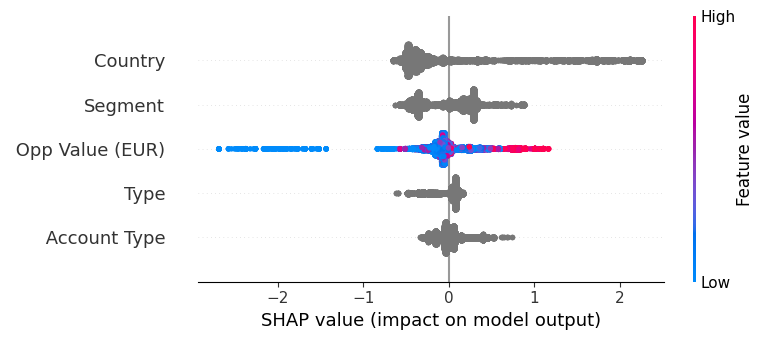

In [29]:
# Plotar o gráfico de resumo global (Summary Plot)
shap.summary_plot(shap_values, X_test_cat)

### Local Explanation - Force Plot

Para entender por que o modelo fez uma previsão específica para um exemplo, usar o Force Plot do SHAP.

In [30]:
# Visualizar o SHAP values para a primeira instância de teste
shap.initjs()  # Necessário para visualizações interativas no Jupyter
# Get the expected value from the explainer
expected_value = explainer.expected_value

# If it is a multi-class classification, you might need to access the specific class:
# expected_value = explainer.expected_value[0] # Use the appropriate class index

shap.force_plot(expected_value, shap_values[0], X_test_cat.iloc[0])  # Pass the base/expected value and the instance data

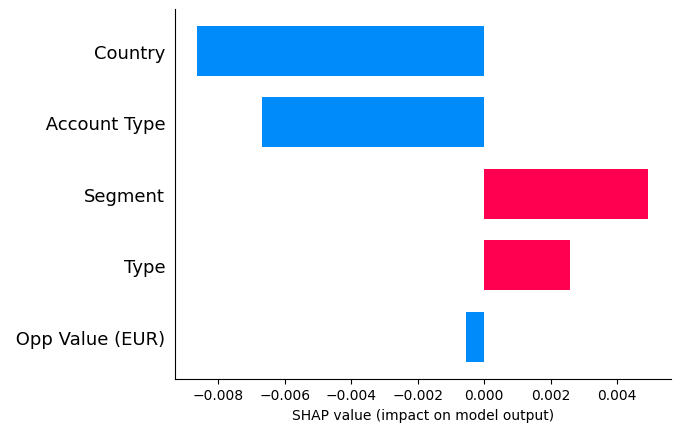

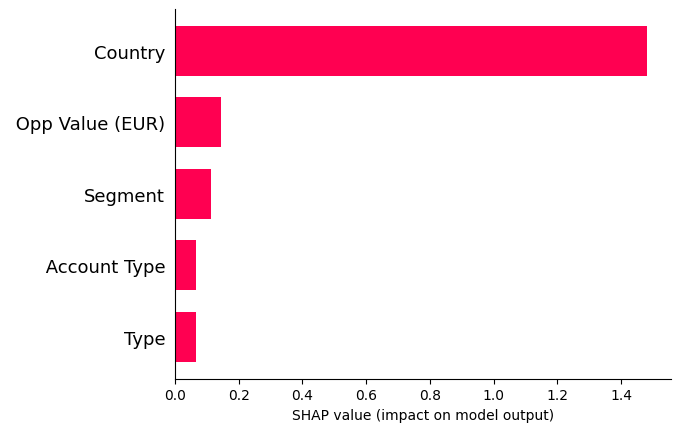

In [31]:
feature_names = X_test_cat.columns

shap.bar_plot(shap_values.mean(0), feature_names=feature_names) # using the mean for global explanation

# Plot de barras com as variáveis mais importantes
shap.bar_plot(shap_values[0], feature_names=feature_names) # using the first sample for local explanation

## Predictions With New Entry

In [32]:
print(data_to_model[" Account Type"].unique())
print(data_to_model["Country"].unique())
print(data_to_model["Segment"].unique())
print(data_to_model["Type"].unique())

[' Top 2' ' Small' ' Top 3' ' Top 1']
['Country 1' 'Country 2' 'Country 5']
['Segment 1' 'Segment 3' 'Segment 2' 'Segment 4']
['New Business' 'Existing Business']


In [33]:
# 1. Verifique se a feature está sendo utilizada:
print(cat_clf_final.feature_names_)

# 2. Analise a importância da feature:
importances = cat_clf_final.get_feature_importance()
feature_importances = pd.DataFrame({'feature': cat_clf_final.feature_names_, 'importance': importances})
print(feature_importances.sort_values(by='importance', ascending=False))

[' Account Type', 'Country', 'Segment', 'Type', ' Opp Value (EUR)']
            feature  importance
1           Country   36.539628
4   Opp Value (EUR)   30.065106
2           Segment   16.817167
0      Account Type   10.461186
3              Type    6.116912


In [44]:
new_entry = pd.DataFrame({
    ' Account Type': [' Top 3'],
    'Country': ['Country 1'],
    'Segment': ['Segment 2'],
    'Type': ['Existing Business'],
    ' Opp Value (EUR)': [500]
}, index=[0])

prediction = cat_clf_final.predict(new_entry)
print(prediction)

prediction_proba = cat_clf_final.predict_proba(new_entry)
print(prediction_proba)

## ------- SHAP Local ------

# Criar o objeto explainer SHAP para CatBoost
explainer_new_entries = shap.TreeExplainer(cat_clf_final)

# Calcular os SHAP values para o conjunto de dados de teste
shap_values_new_entries = explainer_new_entries.shap_values(new_entry)

# Visualizar o SHAP values para a primeira instância de teste
shap.initjs()  # Necessário para visualizações interativas no Jupyter

# Get the expected value from the explainer
expected_value = explainer.expected_value

# If it is a multi-class classification, you might need to access the specific class:
# expected_value = explainer.expected_value[0] # Use the appropriate class index

shap.force_plot(expected_value, shap_values_new_entries[0], new_entry.iloc[0])  # Pass the base/expected value and the instance data

[1]
[[0.22693566 0.77306434]]


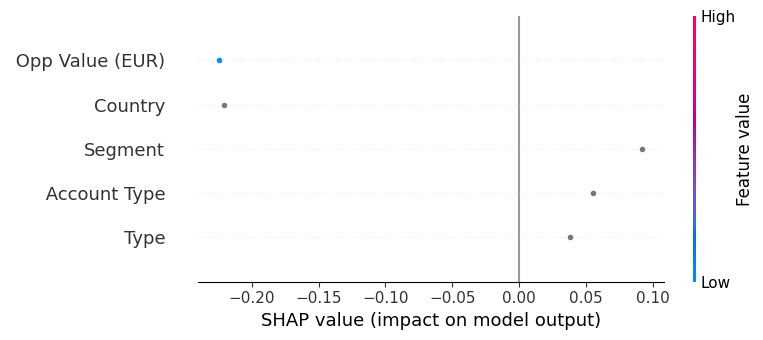

In [36]:
# Plotar o gráfico de resumo global (Summary Plot)
shap.summary_plot(shap_values_new_entries, new_entry)

## Saving the Models:

In [37]:
import pickle

# Define o caminho para a pasta onde você baixou os dados
data_folder = "/content/drive/Othercomputers/Meu laptop/Documents/Projects/merck_business_case/data/"

# Salva o modelo base
with open(data_folder + "catboost_base_model.pkl", "wb") as f:
    pickle.dump(cat_clf_base, f)

# Salva o modelo tunned
with open(data_folder + "catboost_tuned_model.pkl", "wb") as f:
    pickle.dump(cat_clf_tuned, f)

## Loading the Models:

In [38]:
import pickle

# Define o caminho para a pasta onde você baixou os dados
data_folder = "/content/drive/Othercomputers/Meu laptop/Documents/Projects/merck_business_case/data/"

# Carrega o modelo base
with open(data_folder + "catboost_base_model.pkl", "rb") as f:
    loaded_base_model = pickle.load(f)

# Carrega o modelo tunned
with open(data_folder + "catboost_tuned_model.pkl", "rb") as f:
    loaded_tuned_model = pickle.load(f)